# Day5: 인공지능 컴퓨터 비젼

## 학습 내용
1. Roboflow 사용법
2. Yolov11을 이용한 object detection 학습

In [ ]:
# !pip install -qU ultralytics roboflow

import os
import cv2
import sys
import numpy as np
import matplotlib.pyplot as plt

import ultralytics
import yaml

## 1. YOLO 사용법

In [12]:
classNames = ["person", "bicycle", "car", "motorbike", "aeroplane", "bus", "train", "truck", "boat",
              "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat",
              "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella",
              "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat",
              "baseball glove", "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
              "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli",
              "carrot", "hot dog", "pizza", "donut", "cake", "chair", "sofa", "pottedplant", "bed",
              "diningtable", "toilet", "tvmonitor", "laptop", "mouse", "remote", "keyboard", "cell phone",
              "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors",
              "teddy bear", "hair drier", "toothbrush"
              ]

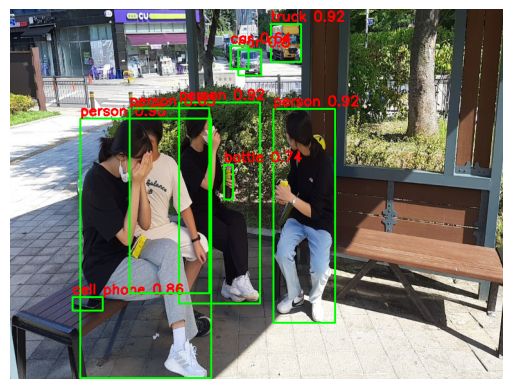

In [ ]:
# --- 1. 이미지 로드 및 모델 초기화 ---
data_dir = "./fig"

img_path = os.path.join(data_dir, "peoples.jpg") # 이미지 전체 경로 생성
img = cv2.imread(img_path) # OpenCV를 사용하여 이미지 파일(BGR 형식)을 메모리로 로드

# 이미지 로드 성공 여부 확인
# 실패 시 프로그램 종료
if img is None:
    print("Image read failed")
    sys.exit()

# Ultralytics 라이브러리를 사용하여 사전 학습된 YOLO 모델 로드
model = ultralytics.YOLO("yolo11x.pt")  # load a pretrained model (recommended for training)

# 이미지에 대해 객체 감지 수행. 결과 리스트에서 첫 번째(인덱스 0) 감지 결과만 사용
detection = model(img, verbose=False)[0]
# detection[0].boxes.data.tolist() 

# 최소 신뢰도(Confidence) 임계값 설정 (60%)
CONFIDENCE_THRESHOLD = 0.6

# --- 2. 감지 결과 반복 처리 및 시각화 ---
# 감지된 모든 바운딩 박스 데이터를 리스트로 변환하여 반복
for data in detection.boxes.data.tolist():
        
        # 리스트의 다섯 번째 요소 (인덱스 4)는 신뢰도(확률) 값
        confidence = data[4]  
        if confidence < CONFIDENCE_THRESHOLD:
            continue

        # 바운딩 박스 좌표 추출 (xmin, ymin, xmax, ymax) 및 정수형으로 변환
        xmin, ymin, xmax, ymax = int(data[0]), int(data[1]), int(data[2]), int(data[3])
        label = int(data[5]) # 리스트의 여섯 번째 요소 (인덱스 5)는 클래스 ID
        # 바운딩 박스를 이미지에 그림 (녹색, 두께 2)
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
        # 클래스 이름과 신뢰도를 문자열로 구성
        cv2.putText(img, classNames[label]+ ' ' +str(round(confidence, 2)), 
        (xmin, ymin-5), cv2.FONT_ITALIC, 0.7, (0, 0, 255), 2)        

# --- 3. 이미지 출력 (Matplotlib) ---
img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.grid(None)
plt.axis("off")
plt.show()

## 2. YOLO 학습: Hymenoptera_data

### hymenoptera_data 자료 다운로드

In [ ]:
# !pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Person-API")
project = rf.workspace("firedetection-ysypi").project("hymenoptera-tffvh")
version = project.version(1)
dataset = version.download("yolov11")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to hymenoptera-1 in yolov11:: 100%|██████████| 44/44 [00:00<00:00, 1192.40it/s]


### Label images dataset
- bounding box와 클래스를 포함한 자료 (예, roboflow, labelImg)
- yaml 파일 만들기

In [ ]:
data = {
    'train' : './hymenoptera-1/train/images', # 'train': 훈련 이미지 파일들이 위치한 디렉토리 경로
    'val' : './hymenoptera-1/valid/images', # 'val': 검증 이미지 파일들이 위치한 디렉토리 경로
    'test' : './hymenoptera-1/test/images', # 'test': 테스트 이미지 파일들이 위치한 디렉토리 경로 (선택 사항)
    'names' : ["ant", "bee"], # 클래스 이름 목록 (알파벳 순서에 따라 ID가 할당됨, 0: ant, 1: bee)
    'nc' : 2 # 'nc': 클래스의 총 개수 (Number of Classes)
}
# 'hymenoptera-1/data.yaml' 파일을 쓰기 모드('w')로 열고 파일 객체를 'f'로 지정
with open('./hymenoptera-1/data.yaml', 'w') as f:
    yaml.dump(data, f)

In [ ]:
model = ultralytics.YOLO('yolo11n.pt')
print(model.names) 

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

### Yolo v11 hymenoptera data 객체검출 학습

In [ ]:
model.train(data = './hymenoptera-1/data.yaml', epochs = 20, patience = 10, imgsz = 256)

# 훈련 지표 (Training Metrics)
# GPU_mem (0.516G): 현재 모델이 사용하고 있는 GPU(그래픽 처리 장치) 메모리 양.
# box_loss (1.365): 바운딩 박스 회귀와 관련된 손실 값. 예측된 바운딩 박스가 실제 바운딩 박스와 위치, 너비, 높이 면에서 얼마나 잘 일치하는지를 정량화
# cls_loss (1.328): 분류 손실. 모델이 탐지된 각 객체에 대해 올바른 클래스를 얼마나 잘 예측하는지를 측정
# dfl_loss (1.056): DFL(Distribution Focal Loss)의 약자입니다. 이 손실은 현대 객체 탐지 모델(일부 YOLO 버전과 같은)에서 모델이 분류하기 어려운 예시에 집중
# Instances (1): 현재 반복(iteration)에서 처리된 인스턴스 또는 배치(batch)의 수
# Size (256): 모델이 처리하는 입력 이미지의 크기(예: 256x256 픽셀)입니다.

# 평가 지표 (Evaluation Metrics)
# Images (2047): 검증/평가 데이터셋에 있는 총 이미지 수
# Instances (2194): 검증/평가 데이터셋의 모든 이미지에 걸쳐 있는 실제 객체 인스턴스(바운딩 박스)의 총 수
# Box (P: Precision, R: Recall, mAP50, mAP50-95):
# P (Precision, 정밀도): 모델이 '있다'고 예측한 것 중 실제로 맞는 것의 비율
# R (Recall, 재현율): 실제로 있어야 할 객체 중 모델이 얼마나 많이 찾아냈는지를 나타냄
# mAP50 (평균 정밀도, IoU 0.5): IoU(Intersection over Union, 겹침 영역 비율) 임계값을 0.5로 설정했을 때의 평균 정밀도
# mAP50-95 (평균 정밀도, IoU 0.5~0.95): IoU 임계값을 0.5부터 0.95까지 0.05 단위로 증가시키면서 계산한 평균 정밀도들의 평균

In [ ]:
# 'model_path' 변수에 학습된 YOLO 모델의 가중치 파일 경로를 정의
# 'best.pt'는 학습 중 가장 성능이 좋았던 모델 가중치 파일
model_path = './runs/detect/train/weights/best.pt'
# Ultralytics 라이브러리의 YOLO 클래스를 사용하여 지정된 경로에서 모델을 로드
model = ultralytics.YOLO(model_path)

In [ ]:
# 'model' 객체를 사용하여 객체 감지(Inference)를 실행
# source: 감지 대상 이미지 파일들이 들어있는 디렉토리 경로를 지정
#         이 디렉토리의 모든 이미지에 대해 감지가 수행
# save: 감지 결과(바운딩 박스가 그려진 이미지)를 디스크에 저장하도록 지시
# 'result' 변수에는 감지 결과에 대한 상세 정보(예: 박스 좌표, 신뢰도 등)가 담긴 객체 목록이 할당
result = model(source = './hymenoptera-1/test/images', save = True)


image 1/2 /content/ant_bee/test/images/153320619_2aeb5fa0ee_jpg.rf.aa8b37b12abcbda3ad6a58e356b1c434.jpg: 256x256 (no detections), 13.3ms
image 2/2 /content/ant_bee/test/images/6a00d8341c630a53ef00e553d0beb18834-800wi_jpg.rf.ecc94648169630a9ddf8e7c78b4947b1.jpg: 256x256 (no detections), 11.1ms
Speed: 1.1ms preprocess, 12.2ms inference, 1.0ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/predict2
